# MovieLens: Polars vs Pandas para Análisis y Predicción de Preferencias de Películas
El objetivo de este proyecto es construir un pipeline completo utilizando Polars para análisis de datos, ingeniería de características y aprendizaje automático, comparándolo posteriormente con una implementación equivalente en Pandas para evaluar rendimiento y escalabilidad.

## Configuración del entorno

### Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    load_ratings_polars,
    load_movies_polars,
    get_dataset_info,
    get_missing_values,
    get_dataset_size,
    get_system_info,
)

from src.polars_pipeline import run_polars_pipeline
from src.pandas_pipeline import run_pandas_pipeline

from src.train_models import train_all_models

### Información del Sistema

In [2]:
system_info = get_system_info()

for key, value in system_info.items():
    print(f"{key:<20}: {value}")

cpu_cores           : 8
total_ram_gb        : 16.0


## Carga de datos
En esta sección se cargan los datasets ratings.csv y movies.csv utilizando Polars. Además, se presenta información general sobre el tamaño y la estructura de ambos conjuntos de datos, con el objetivo de verificar que la información se haya cargado correctamente antes de iniciar el análisis exploratorio.

In [4]:
ratings = load_ratings_polars("../data/raw/ratings.csv")
movies = load_movies_polars("../data/raw/movies.csv")

In [5]:
ratings_info = get_dataset_info(ratings)
movies_info = get_dataset_info(movies)

print(ratings_info)
print(movies_info)

{'rows': 100836, 'columns': 4, 'column_names': ['userId', 'movieId', 'rating', 'timestamp']}
{'rows': 86537, 'columns': 3, 'column_names': ['movieId', 'title', 'genres']}


## EDA

### Descripción General del Dataset

In [6]:
ratings_info = get_dataset_info(ratings)
movies_info = get_dataset_info(movies)

pd.DataFrame([
    {
        "Dataset": "Ratings",
        "Rows": ratings_info["rows"],
        "Columns": ratings_info["columns"],
        "Size (MB)": get_dataset_size("../data/raw/ratings.csv"),
    },
    {
        "Dataset": "Movies",
        "Rows": movies_info["rows"],
        "Columns": movies_info["columns"],
        "Size (MB)": get_dataset_size("../data/raw/movies.csv"),
    }
])

,Dataset,Rows,Columns,Size (MB)
0,Ratings,100836,4,2.368663
1,Movies,86537,3,3.998122


El dataset ratings contiene las calificaciones otorgadas por los usuarios, mientras que movies almacena la información descriptiva de cada película. Ambos conjuntos se relacionan mediante la columna movieId.

### Estadísticas Descriptivas

In [8]:
ratings.describe()

statistic,userId,movieId,rating,timestamp
str,f64,f64,f64,f64
"""count""",100836.0,100836.0,100836.0,100836.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",326.127564,19435.295718,3.501557,1.2059e9
"""std""",182.618491,35530.987199,1.042529,2.1626e8
"""min""",1.0,1.0,0.5,8.28124615e8
"""25%""",177.0,1199.0,3.0,1.0191e9
"""50%""",325.0,2991.0,3.5,1.1861e9
"""75%""",477.0,8121.0,4.0,1.4360e9
"""max""",610.0,193609.0,5.0,1.5378e9


In [7]:
print(f"Unique Users   : {ratings['userId'].n_unique()}")
print(f"Unique Movies  : {ratings['movieId'].n_unique()}")
print(f"Average Rating : {ratings['rating'].mean():.2f}")
print(f"Total Ratings  : {ratings.shape[0]:,}")

Unique Users   : 610
Unique Movies  : 9724
Average Rating : 3.50
Total Ratings  : 100,836


### Missing Values

In [10]:
missing_ratings = get_missing_values(ratings)

missing_ratings

userId,movieId,rating,timestamp
u32,u32,u32,u32
0,0,0,0


In [11]:
missing_movies = get_missing_values(movies)

missing_movies

movieId,title,genres
u32,u32,u32
0,0,0


### Distribución de Ratings

In [23]:
rating_counts = (
    ratings
    .group_by("rating")
    .len()
    .sort("rating")
)

rating_counts

rating,len
f64,u32
0.5,1370
1.0,2811
1.5,1791
2.0,7551
2.5,5550
3.0,20047
3.5,13136
4.0,26818
4.5,8551


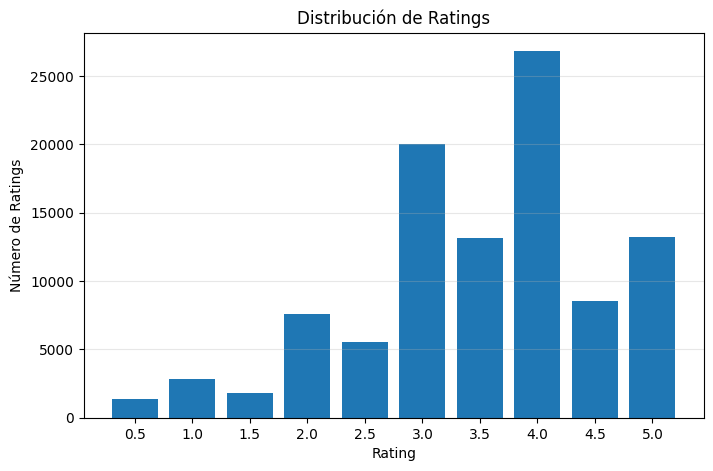

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    rating_counts["rating"],
    rating_counts["len"],
    width=0.4
)

plt.xticks(rating_counts["rating"])

plt.title("Distribución de Ratings")
plt.xlabel("Rating")
plt.ylabel("Número de Ratings")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Análisis de Usuarios

In [25]:
user_activity = (
    ratings
    .group_by("userId")
    .len()
)

In [26]:
user_activity.describe()

statistic,userId,len
str,f64,f64
"""count""",610.0,610.0
"""null_count""",0.0,0.0
"""mean""",305.5,165.304918
"""std""",176.236111,269.480584
"""min""",1.0,20.0
"""25%""",153.0,35.0
"""50%""",306.0,71.0
"""75%""",458.0,168.0
"""max""",610.0,2698.0


### Análisis de Películas

In [27]:
movie_activity = (
    ratings
    .group_by("movieId")
    .len()
)

In [28]:
movie_activity.describe()

statistic,movieId,len
str,f64,f64
"""count""",9724.0,9724.0
"""null_count""",0.0,0.0
"""mean""",42245.024373,10.369807
"""std""",52191.13732,22.401005
"""min""",1.0,1.0
"""25%""",3246.0,1.0
"""50%""",7301.0,3.0
"""75%""",76738.0,9.0
"""max""",193609.0,329.0


### Distribución de Géneros

In [29]:
genre_counts = (
    movies
    .with_columns(
        pl.col("genres").str.split("|")
    )
    .explode("genres")
    .group_by("genres")
    .len(name="movie_count")
    .sort("movie_count", descending=True)
)

genre_counts

genres,movie_count
str,u32
"""Drama""",33681
"""Comedy""",22830
"""Thriller""",11675
"""Romance""",10172
"""Action""",9563
…,…
"""War""",2301
"""Western""",1690
"""Musical""",1059


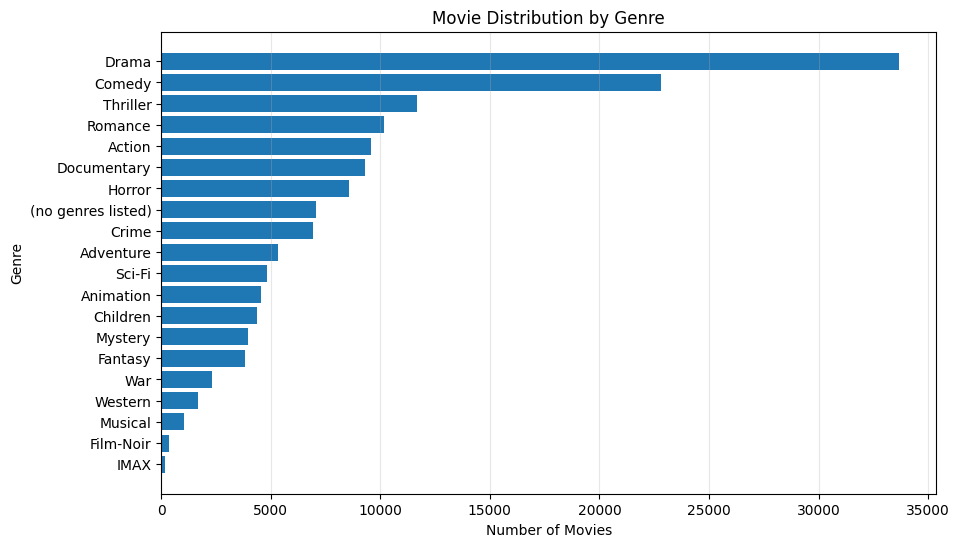

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    genre_counts["genres"],
    genre_counts["movie_count"]
)

plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.title("Movie Distribution by Genre")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()

### Principales hallazgos del EDA

- El conjunto de datos contiene 100,836 calificaciones, realizadas por 610 usuarios sobre 9,724 películas, proporcionando un volumen adecuado para el desarrollo de modelos de Machine Learning.
- No se identificaron valores faltantes en ninguno de los datasets, por lo que no será necesario realizar procesos de imputación durante el preprocesamiento.
- Las calificaciones presentan una mayor concentración entre 3.0 y 5.0, siendo 4.0 la valoración más frecuente. Esto respalda la definición de una valoración positiva como aquellas con rating ≥ 4.0.
- La actividad de los usuarios es altamente heterogénea, existiendo usuarios con pocas calificaciones y otros con miles de valoraciones registradas.
- La popularidad de las películas también presenta una distribución desigual, donde la mayoría recibe pocas calificaciones mientras que un reducido grupo concentra gran parte de las interacciones.
- El dataset incluye una amplia diversidad de géneros cinematográficos. Debido a que una película puede pertenecer a múltiples géneros, será necesario transformar esta información en variables binarias durante la etapa de ingeniería de características.

## Pipeline Polars
### Ejecución del pipeline

In [ ]:
# Ejecución del pipeline de Polars
train_df, test_df, timings_polars = run_polars_pipeline(
    ratings_path="../data/raw/ratings.csv",
    movies_path="../data/raw/movies.csv",
)

### Resultados del Preprocesamiento

In [ ]:
print(f"Training samples : {train_df.height:,}")
print(f"Testing samples  : {test_df.height:,}")

print(f"Training features: {train_df.width}")
print(f"Testing features : {test_df.width}")

Training samples : 80,200
Testing samples  : 20,050
Training features: 28
Testing features : 28


In [ ]:
print("Training Set")
display(
    train_df
    .group_by("liked_movie")
    .len()
    .sort("liked_movie")
)

print("Testing Set")
display(
    test_df
    .group_by("liked_movie")
    .len()
    .sort("liked_movie")
)

Training Set


liked_movie,len
i8,u32
0,41574
1,38626


Testing Set


liked_movie,len
i8,u32
0,10393
1,9657


### Resultados Feature Engineering

In [26]:
feature_columns = [
    "user_avg_rating",
    "user_num_ratings",
    "movie_avg_rating",
    "movie_num_ratings",
]

train_df.select(feature_columns).head()

user_avg_rating,user_num_ratings,movie_avg_rating,movie_num_ratings
f64,u32,f64,u32
4.081169,154,3.90411,73
3.883495,103,3.961538,117
3.968085,94,3.8,5
3.435233,386,3.5,1
3.9,30,4.170775,284


In [27]:
genre_features = [
    column
    for column in train_df.columns
    if column.startswith("genre_")
]

print(f"Genre Features ({len(genre_features)}):")
genre_features

Genre Features (20):


['genre_(no_genres_listed)',
 'genre_action',
 'genre_adventure',
 'genre_animation',
 'genre_children',
 'genre_comedy',
 'genre_crime',
 'genre_documentary',
 'genre_drama',
 'genre_fantasy',
 'genre_film_noir',
 'genre_horror',
 'genre_imax',
 'genre_musical',
 'genre_mystery',
 'genre_romance',
 'genre_sci_fi',
 'genre_thriller',
 'genre_war',
 'genre_western']

In [21]:
print(f"Total Features: {len(train_df.columns)}")

Total Features: 28


### Métricas del pipeline

In [22]:
pl.DataFrame(
    {
        "Operation": list(timings_polars.keys()),
        "Time (seconds)": list(timings_polars.values()),
    }
)

Operation,Time (seconds)
str,f64
"""loading""",0.005625
"""join""",0.004168
"""filtering""",0.001164
"""missing_values""",0.002603
"""target""",0.000181
"""feature_engineering""",0.028786
"""total""",0.042528


## Machine Learning

### Prepración para Machine Learning

### Logistic Regression

### Random Forest

### Gradient Boosting

### Comparación de Modelos

## Pipeline Pandas

### Preprocesamiento

### Feature Engineering

### Métricas del pipeline

## Benchmark Polars vs Pandas

## Escalabilidad

## Lazy Execution

## Conclusiones